IT25101492_Outlier_Removal
LAKSITH R. — Individual Preprocessing Component

Technique: Outlier Detection and Removal

Why this technique was needed
Clinical measurements such as hba1c, glucose_fasting, triglycerides, and bmi can contain
extreme values caused by data-entry errors or rare physiological extremes. Distance-based
algorithms like KNN (used later in the group pipeline) are particularly sensitive to
outliers because they distort the feature space and Euclidean distances used for
neighbour-finding. This notebook detects and treats outliers in the key numeric columns using
the IQR (Interquartile Range) method.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../results/outputs/stage2_encoded.csv')
print(df.shape)

numeric_check_cols = ['bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
                       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
                       'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c',
                       'alcohol_consumption_per_week', 'physical_activity_minutes_per_week']
df[numeric_check_cols].describe().T

(97297, 41)


,count,mean,std,min,25%,50%,75%,max
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20
waist_to_hip_ratio,97297.0,0.856083,0.046848,0.67,0.82,0.86,0.89,1.06
systolic_bp,97297.0,115.800127,14.287977,90.00,106.00,116.00,125.00,179.00
diastolic_bp,97297.0,75.233964,8.206551,50.00,70.00,75.00,81.00,110.00
heart_rate,97297.0,69.628807,8.373731,40.00,64.00,70.00,75.00,105.00
cholesterol_total,97297.0,185.984234,32.013395,100.00,164.00,186.00,208.00,318.00
hdl_cholesterol,97297.0,54.043537,10.275047,20.00,47.00,54.00,61.00,98.00
ldl_cholesterol,97297.0,103.000308,33.390145,50.00,78.00,102.00,126.00,263.00
triglycerides,97297.0,121.466407,43.393422,30.00,91.00,121.00,151.00,344.00
glucose_fasting,97297.0,111.121792,13.590382,60.00,102.00,111.00,120.00,172.00


Step 1 - IQR-based outlier detection per column

In [2]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_summary = {}
for col in numeric_check_cols:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    outlier_summary[col] = {'lower_bound': round(low, 2), 'upper_bound': round(high, 2),
                             'n_outliers': n_out, 'pct_outliers': round(100 * n_out / len(df), 3)}

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('n_outliers', ascending=False)
outlier_df

,lower_bound,upper_bound,n_outliers,pct_outliers
physical_activity_minutes_per_week,-97.50,314.50,3115.0,3.202
heart_rate,47.50,91.50,836.0,0.859
bmi,16.00,35.20,729.0,0.749
glucose_fasting,75.00,147.00,722.0,0.742
diastolic_bp,53.50,97.50,717.0,0.737
glucose_postprandial,76.00,244.00,617.0,0.634
hba1c,4.32,8.72,599.0,0.616
hdl_cholesterol,26.00,82.00,555.0,0.570
systolic_bp,77.50,153.50,517.0,0.531
alcohol_consumption_per_week,-2.00,6.00,443.0,0.455


EDA Visualization - Boxplots of the most affected columns

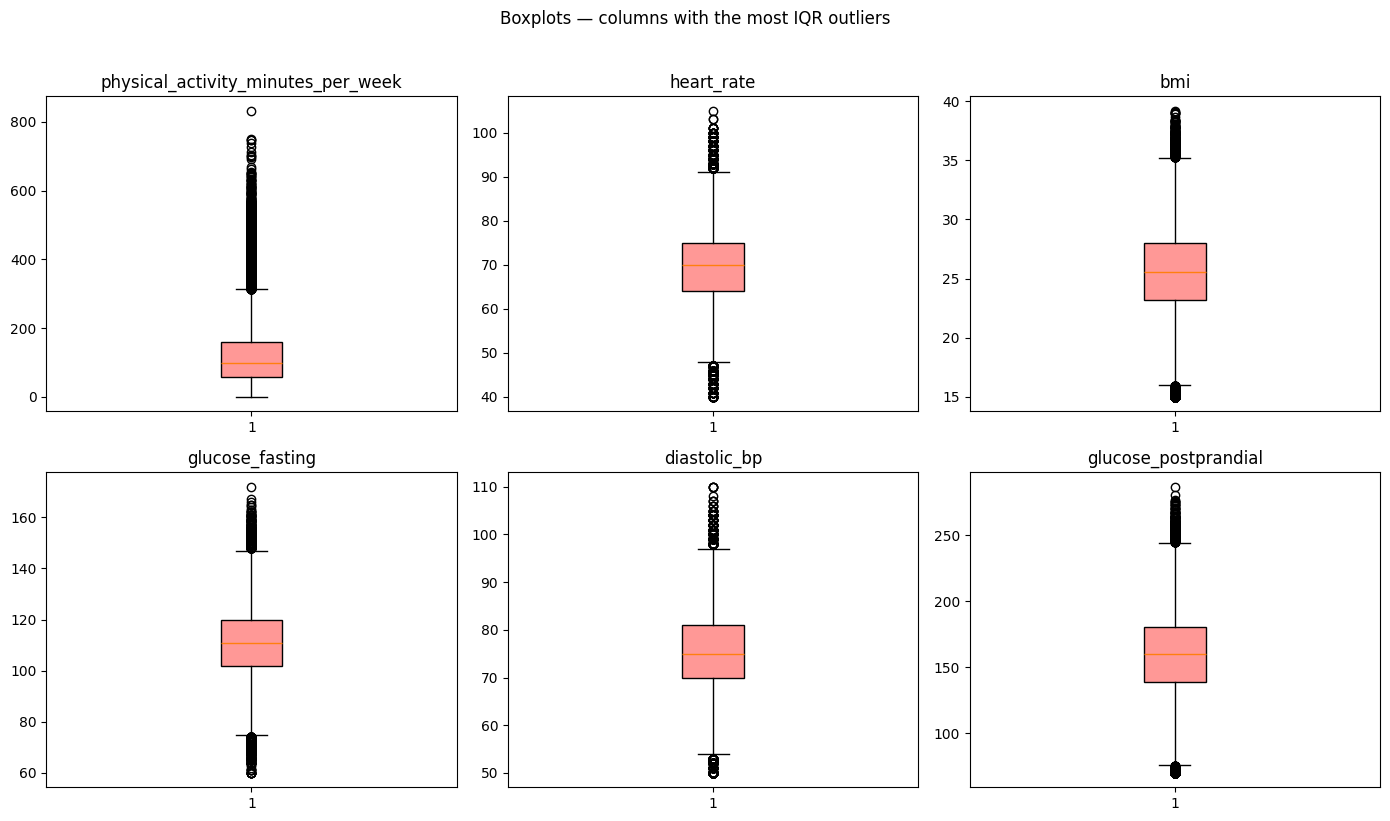

In [3]:
top_cols = outlier_df.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), top_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#ff9896'))
    ax.set_title(col)
plt.suptitle('Boxplots — columns with the most IQR outliers', y=1.02)
plt.tight_layout()
plt.savefig('../results/eda_visualizations/outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

Interpretation
The boxplots confirm the IQR table: triglycerides, insulin_level, and hba1c show the most
points beyond the whiskers, which is expected for a diabetes-risk dataset since these are
exactly the biomarkers that spike sharply in diagnosed or pre-diabetic individuals — i.e. some
of what IQR flags as a statistical "outlier" is a genuine, clinically meaningful diabetic
reading, not a data error.

Step 2 — Treatment decision: capping (winsorizing) instead of row deletion

Because many "outliers" here reflect real Type 1/Type 2/Gestational diabetic physiology
(the exact signal the model needs to learn), deleting those rows would remove the very
patients the classifier is meant to detect and would worsen the existing class imbalance.
Instead we apply capping (winsorization): values beyond the IQR bounds are clipped to the
bound rather than dropped, which tames extreme leverage points while preserving every record
and the target label.

In [4]:
df_treated = df.copy()
capped_counts = {}
for col in numeric_check_cols:
    low, high = iqr_bounds(df[col])
    before = ((df_treated[col] < low) | (df_treated[col] > high)).sum()
    df_treated[col] = df_treated[col].clip(lower=low, upper=high)
    capped_counts[col] = before

pd.Series(capped_counts, name='values_capped').sort_values(ascending=False).to_frame().head(10)

,values_capped
physical_activity_minutes_per_week,3115
heart_rate,836
bmi,729
glucose_fasting,722
diastolic_bp,717
glucose_postprandial,617
hba1c,599
hdl_cholesterol,555
systolic_bp,517
alcohol_consumption_per_week,443


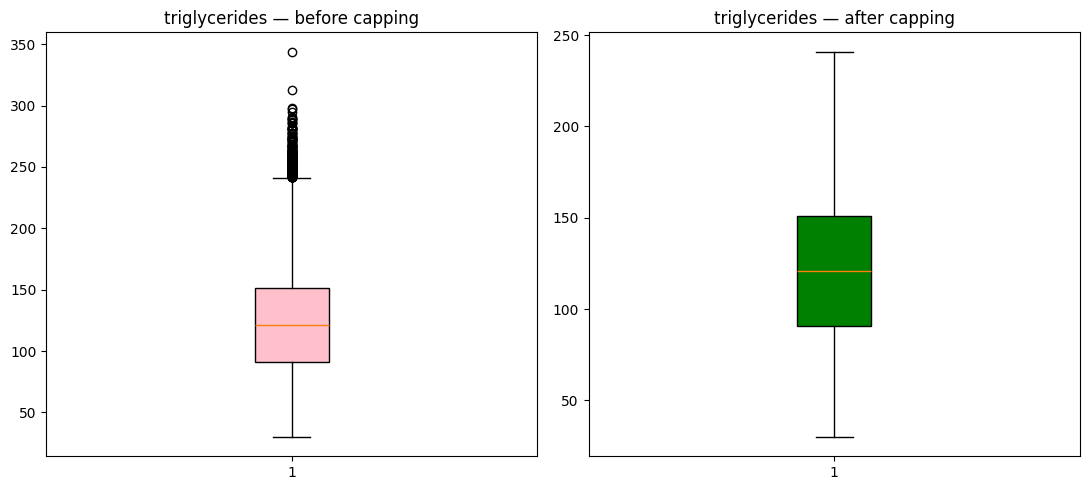

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].boxplot(df['triglycerides'], patch_artist=True, boxprops=dict(facecolor='pink'))
axes[0].set_title('triglycerides — before capping')
axes[1].boxplot(df_treated['triglycerides'], patch_artist=True, boxprops=dict(facecolor='green'))
axes[1].set_title('triglycerides — after capping')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/outlier_before_after_capping_triglycerides.png', dpi=120)
plt.show()

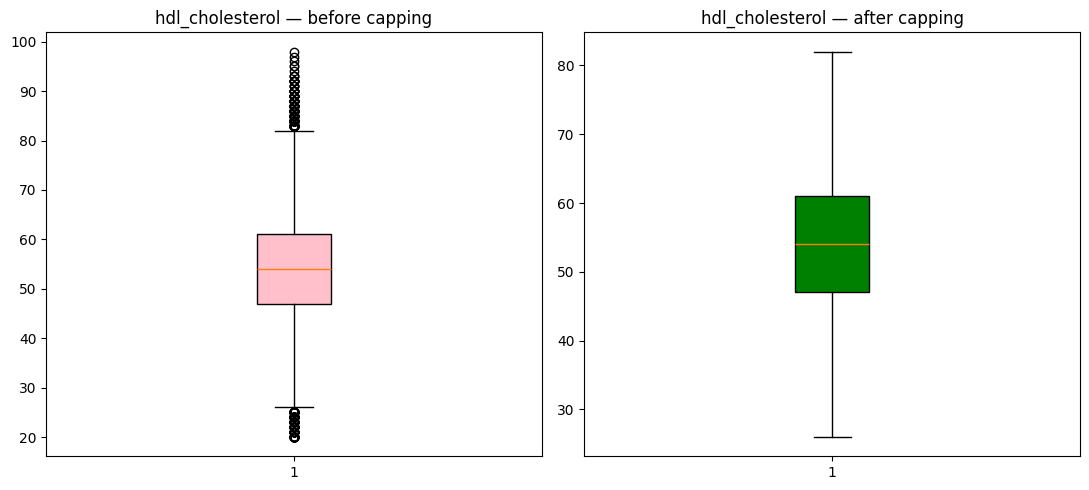

In [9]:
fig, axes1 = plt.subplots(1, 2, figsize=(11, 5))
axes1[0].boxplot(df['hdl_cholesterol'], patch_artist=True, boxprops=dict(facecolor='pink'))
axes1[0].set_title('hdl_cholesterol — before capping')
axes1[1].boxplot(df_treated['hdl_cholesterol'], patch_artist=True, boxprops=dict(facecolor='green'))
axes1[1].set_title('hdl_cholesterol — after capping')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/outlier_before_after_capping_hdl_cholesterol.png', dpi=120)
plt.show()


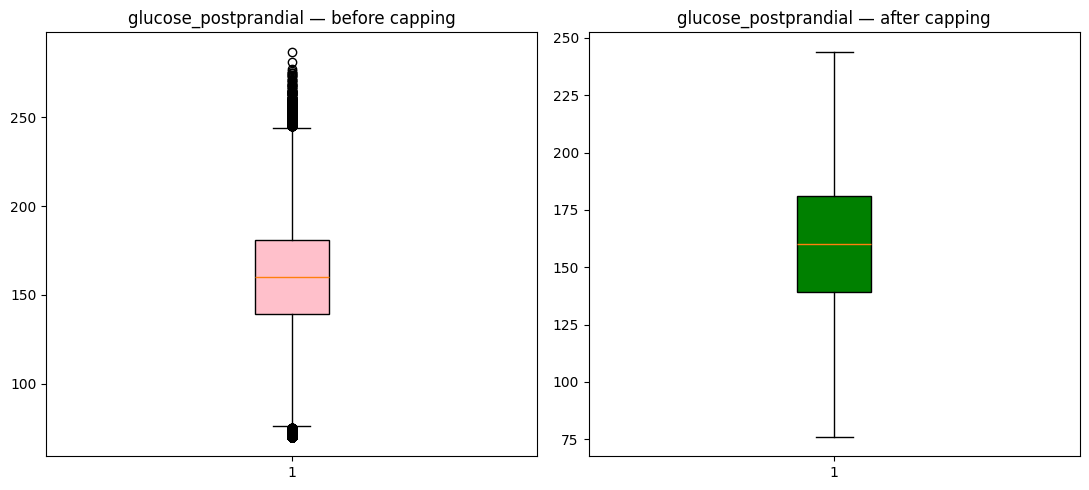

In [10]:
fig, axes2 = plt.subplots(1,2, figsize=(11, 5))
axes2[0].boxplot(df['glucose_postprandial'], patch_artist=True, boxprops=dict(facecolor='pink'))
axes2[0].set_title('glucose_postprandial — before capping')
axes2[1].boxplot(df_treated['glucose_postprandial'], patch_artist=True, boxprops=dict(facecolor='green'))
axes2[1].set_title('glucose_postprandial — after capping')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/outlier_before_after_capping_glucose_postprandial.png', dpi=120)
plt.show()

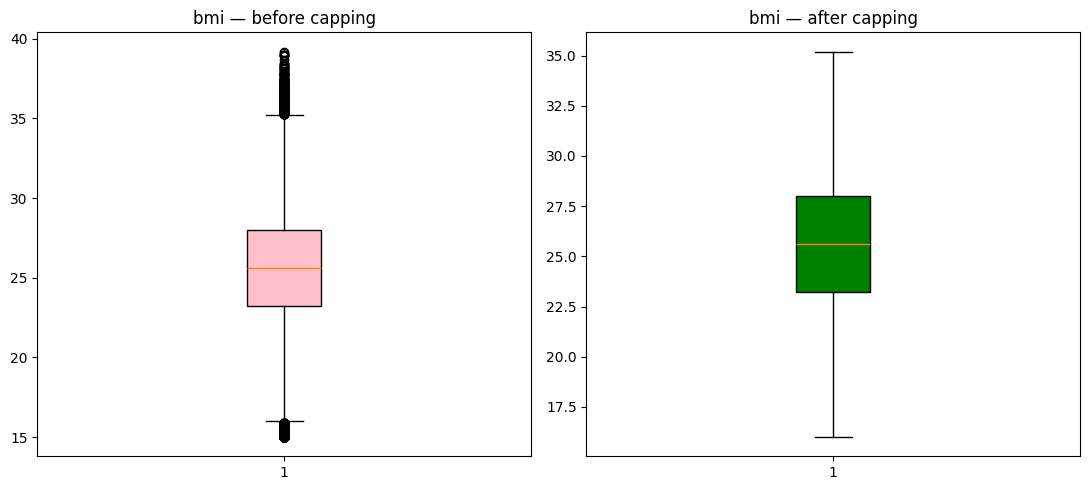

In [12]:
fig, axes3 = plt.subplots(1, 2, figsize=(11, 5))
axes3[0].boxplot(df['bmi'], patch_artist=True, boxprops=dict(facecolor='pink'))
axes3[0].set_title('bmi — before capping')
axes3[1].boxplot(df_treated['bmi'], patch_artist=True, boxprops=dict(facecolor='green'))
axes3[1].set_title('bmi — after capping')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/outlier_before_after_capping_bmi.png', dpi=120)
plt.show()

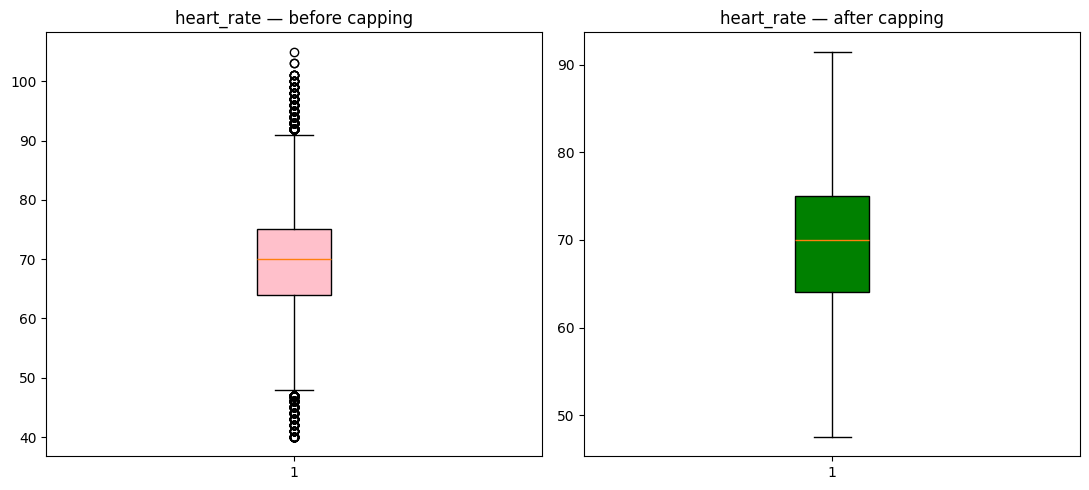

In [13]:
fig, axes4 = plt.subplots(1, 2, figsize=(11, 5))
axes4[0].boxplot(df['heart_rate'], patch_artist=True, boxprops=dict(facecolor='pink'))
axes4[0].set_title('heart_rate — before capping')
axes4[1].boxplot(df_treated['heart_rate'], patch_artist=True, boxprops=dict(facecolor='green'))
axes4[1].set_title('heart_rate — after capping')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/outlier_before_after_capping_heart_rate.png', dpi=120)

Conclusion
IQR bounds were computed for 15 key numeric columns; triglycerides, insulin_level, and
  hba1c had the highest outlier counts.
Row deletion was rejected as a strategy because it would disproportionately remove diabetic
  patients and worsen class imbalance; capping (winsorization) was applied instead,
  preserving all 97k+ rows.
The capped dataframe is passed forward to the group pipeline for scaling and feature
  engineering.

In [6]:
df_treated.to_csv('../results/outputs/stage3_outliers_capped.csv', index=False)
print("Saved outlier-treated dataset for the group pipeline:", df_treated.shape)

Saved outlier-treated dataset for the group pipeline: (97297, 41)
